##Importing Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

##Data Cleaning

In [2]:
df = pd.read_csv('Sport car price.csv')
df.head(10)

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
5,BMW,M8,2022,4.4,617,553,3.1,"130,000"
6,Mercedes-Benz,AMG GT,2021,4,523,494,3.8,"118,500"
7,Chevrolet,Corvette,2021,6.2,490,465,2.8,"59,900"
8,Ford,Mustang Shelby GT500,2022,5.2,760,625,3.5,"81,000"
9,Nissan,GT-R Nismo,2021,3.8,600,481,2.5,"212,000"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Car Make                 1007 non-null   object
 1   Car Model                1007 non-null   object
 2   Year                     1007 non-null   int64 
 3   Engine Size (L)          997 non-null    object
 4   Horsepower               1007 non-null   object
 5   Torque (lb-ft)           1004 non-null   object
 6   0-60 MPH Time (seconds)  1007 non-null   object
 7   Price (in USD)           1007 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.1+ KB


In [4]:
df['Price (in USD)'] = df['Price (in USD)'].str.replace(',', '', regex = False).astype(float)

In [5]:
df['0-60 MPH Time (seconds)'] = df['0-60 MPH Time (seconds)'].str.replace('<', '', regex = False).astype(float)

In [6]:
df['Engine Size (L)'].value_counts()

,count
Engine Size (L),
4,219
6.2,113
3,85
3.5,79
5,68
6.5,46
3.8,38
Electric,36
3.7,35


In [7]:
selected_rows = df[df['Engine Size (L)'].isna()]
selected_rows

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
168,Rimac,C_Two,2022,NaN,1914,1696,1.90,2400000.0
171,Tesla,Model S Plaid,2021,NaN,1020,1050,1.98,131190.0
222,Porsche,Taycan Turbo S,2021,NaN,750,774,2.60,185000.0
247,Tesla,Model S Plaid,2022,NaN,1020,1050,1.90,131190.0
387,Rimac,C_Two,2022,NaN,1888,1696,1.80,2400000.0
389,Tesla,Roadster,2022,NaN,10000+,0,1.90,200000.0
686,Rimac,C_Two,2022,NaN,1914,1696,1.85,2400000.0
697,Lotus,Evija,2022,NaN,1972,1254,2.50,2700000.0
752,Porsche,Taycan,2022,NaN,469,479,3.80,79900.0
916,Tesla,Roadster,2022,NaN,"10,000+",NaN,1.90,200000.0


In [8]:
df['Engine Size (L)'] = df['Engine Size (L)'].fillna(value='Electric')
engines = df['Engine Size (L)'].to_numpy()

for i in range(len(engines)):
  if 'Hybrid' in engines[i]:
    engines[i] = 'Hybrid'
  elif 'Electric' in engines[i] or '-' in engines[i] or '0' in engines[i]:
    engines[i] = 'Electric'
  else:
    continue

df['Engine Size (L)'].value_counts()

,count
Engine Size (L),
4,219
6.2,113
3,85
3.5,79
5,68
Electric,56
6.5,46
3.8,38
3.7,35


In [9]:
df['Horsepower'].value_counts()

,count
Horsepower,
503,45
591,39
650,31
660,30
416,29
...,...
"10,000+",1
485,1
"1,020",1


In [10]:
df['Horsepower'] = df['Horsepower'].str.replace(',', '', regex = False).str.replace('+', '', regex = False).astype(float)

In [11]:
df['Torque (lb-ft)'].value_counts()

,count
Torque (lb-ft),
590,71
443,47
406,42
516,38
650,36
...,...
"1,180",1
475,1
"1,050",1


In [12]:
df['Torque (lb-ft)'] = (
    df['Torque (lb-ft)']
    .fillna('0')
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace('-', '0', regex=False)
    .astype(float)
)

df.loc[df['Car Model'] == 'Roadster', 'Torque (lb-ft)'] = 7376

df.loc[df['Car Model'] == 'Model S Plaid', 'Torque (lb-ft)'] = 1050

df.loc[
    (df['Car Model'] == 'GrandTurismo') &
    (df['Engine Size (L)'] == 'Electric'),
    'Torque (lb-ft)'
] = 996

In [13]:
df['Powertrain Type'] = df['Engine Size (L)'].apply(
    lambda x: x if x in ['Hybrid', 'Electric'] else 'ICE'
)

df['Engine Size (L)'] = pd.to_numeric(
    df['Engine Size (L)'],
    errors='coerce'
)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Car Make                 1007 non-null   object 
 1   Car Model                1007 non-null   object 
 2   Year                     1007 non-null   int64  
 3   Engine Size (L)          947 non-null    float64
 4   Horsepower               1007 non-null   float64
 5   Torque (lb-ft)           1007 non-null   float64
 6   0-60 MPH Time (seconds)  1007 non-null   float64
 7   Price (in USD)           1007 non-null   float64
 8   Powertrain Type          1007 non-null   object 
dtypes: float64(5), int64(1), object(3)
memory usage: 70.9+ KB


---
##EDA

/tmp/ipykernel_3377/1748659132.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


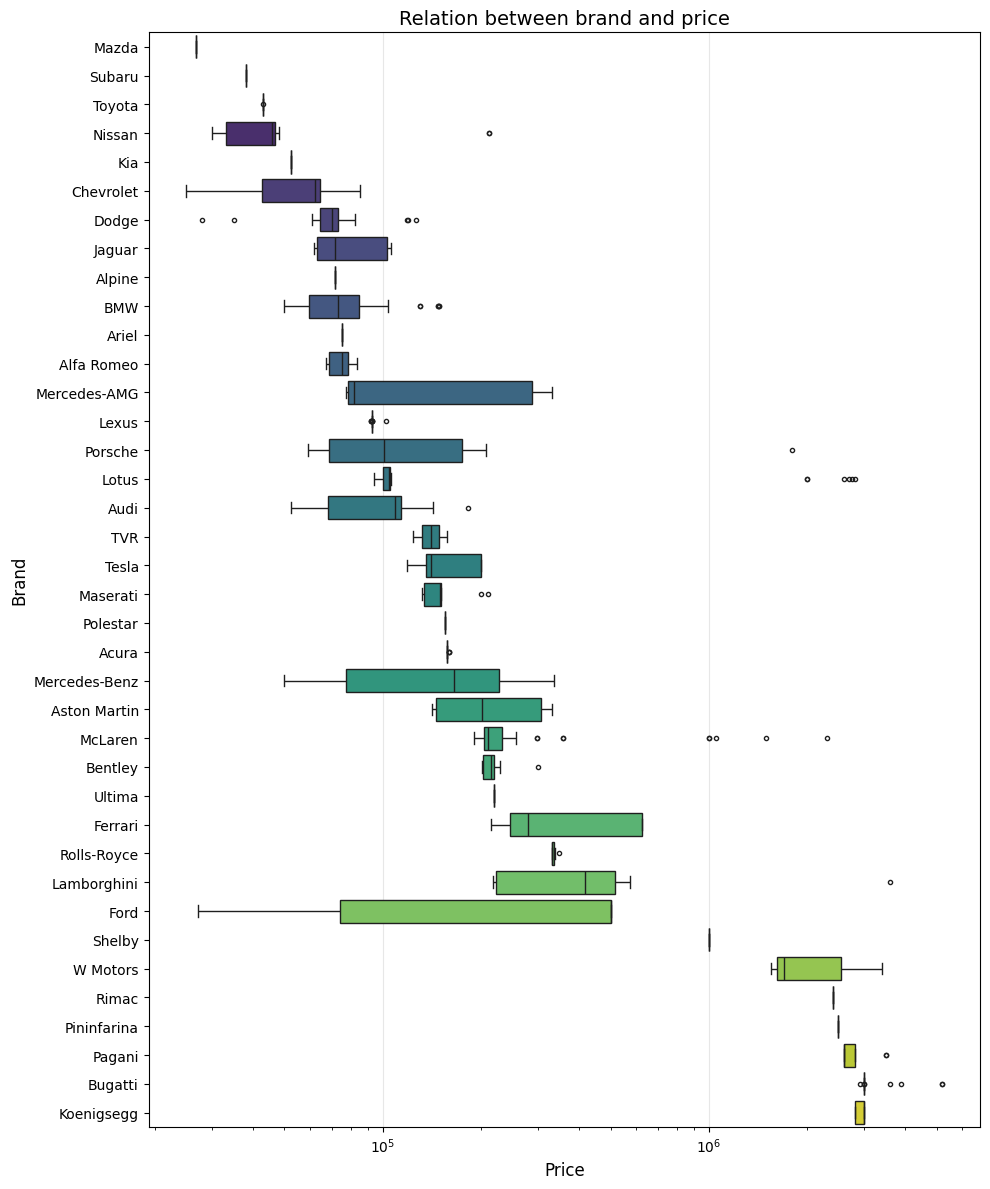

In [15]:
import seaborn as sns

order = df.groupby('Car Make')['Price (in USD)'].median().sort_values().index

plt.figure(figsize=(10, 12))
sns.boxplot(
    data=df,
    y='Car Make',
    x='Price (in USD)',
    order=order,
    palette='viridis',
    fliersize=3
)
plt.xscale('log')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Brand', fontsize=12)
plt.title('Relation between brand and price', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3377/1733713970.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Powertrain Type', y='Price (in USD)', order=df.groupby('Powertrain Type')['Price (in USD)'].median().sort_values().index,


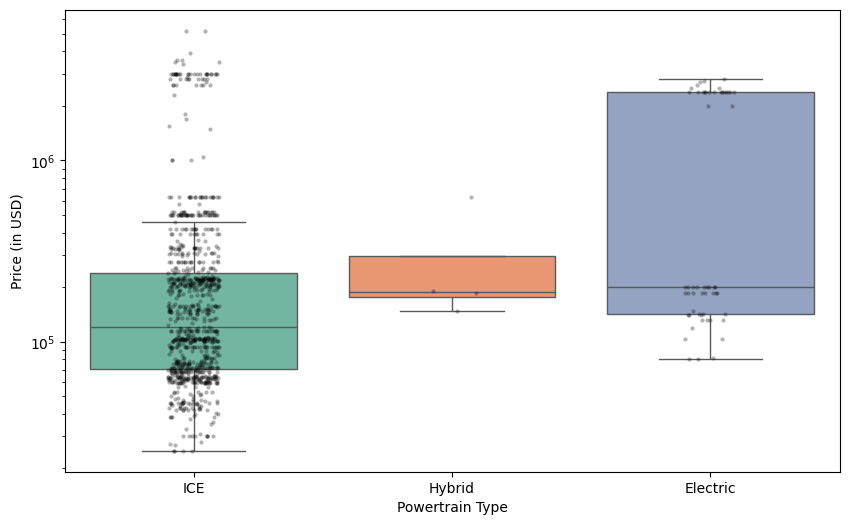

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Powertrain Type', y='Price (in USD)', order=df.groupby('Powertrain Type')['Price (in USD)'].median().sort_values().index,
            palette='Set2', fliersize=0)
sns.stripplot(data=df, x='Powertrain Type', y='Price (in USD)', order=df.groupby('Powertrain Type')['Price (in USD)'].median().sort_values().index,
              color='black', alpha=0.3, size=3, jitter=True)
plt.yscale('log')
plt.show()

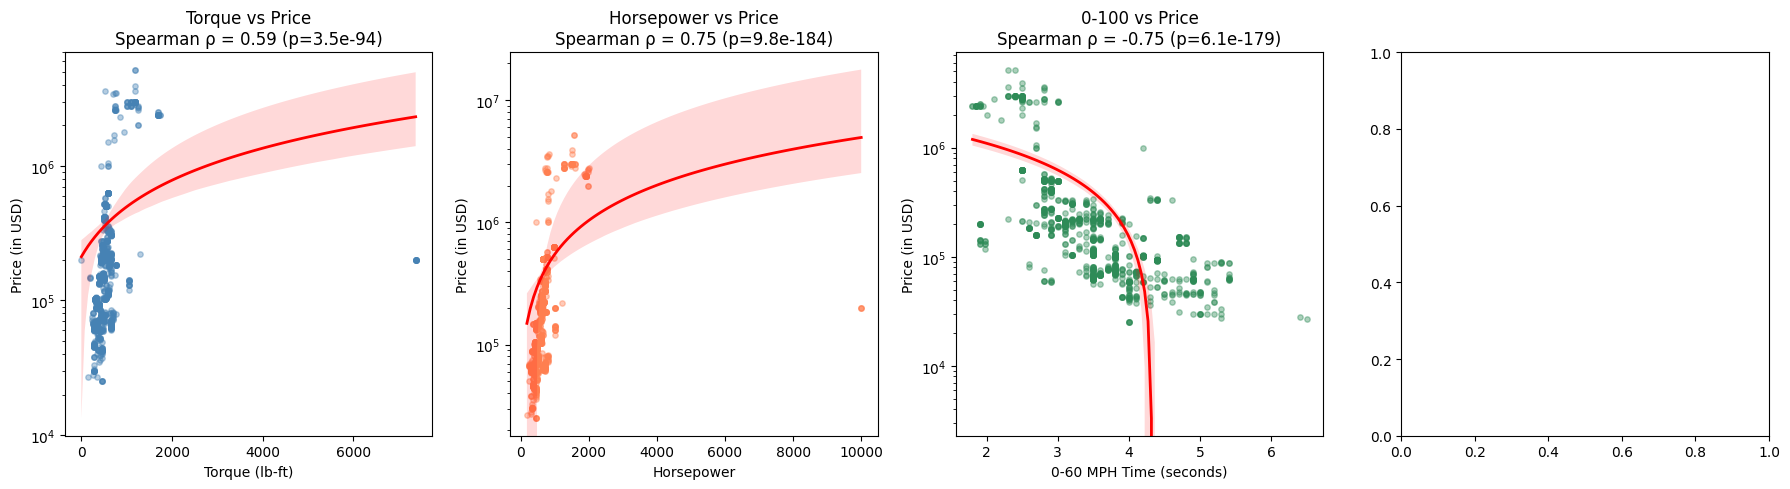

In [17]:
from scipy.stats import spearmanr

cols = ['Torque (lb-ft)', 'Horsepower', '0-60 MPH Time (seconds)', 'Year']
titles = ['Torque vs Price', 'Horsepower vs Price', '0-100 vs Price']
colors = ['steelblue', 'coral', 'seagreen']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, col, title, color in zip(axes, cols, titles, colors):
    sns.regplot(data=df, x=col, y='Price (in USD)', ax=ax,
                scatter_kws={'alpha': 0.4, 's': 15, 'color': color},
                line_kws={'color': 'red', 'linewidth': 2})

    rho, p = spearmanr(df[col], df['Price (in USD)'])
    ax.set_title(f'{title}\nSpearman ρ = {rho:.2f} (p={p:.1e})', fontsize=12)
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

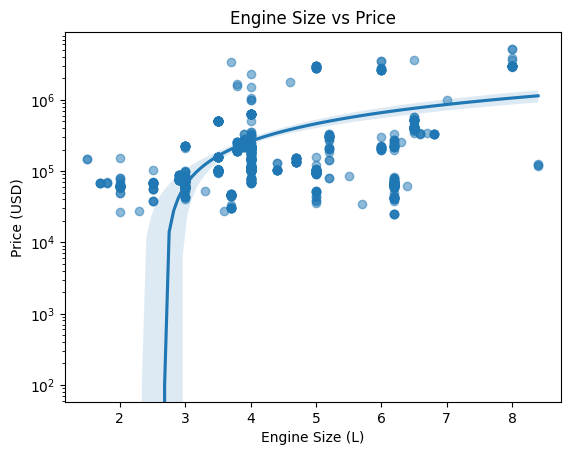

Spearman ρ = 0.32
p-value = 1.90e-24


In [18]:
engine_price = df.dropna(subset=['Engine Size (L)'])

sns.regplot(
    data=engine_price,
    x='Engine Size (L)',
    y='Price (in USD)',
    scatter_kws={'alpha': 0.5}
)

plt.title('Engine Size vs Price')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (USD)')
plt.yscale('log')
plt.show()

rho, p = spearmanr(
    engine_price['Engine Size (L)'],
    engine_price['Price (in USD)']
)

print(f'Spearman ρ = {rho:.2f}')
print(f'p-value = {p:.2e}')

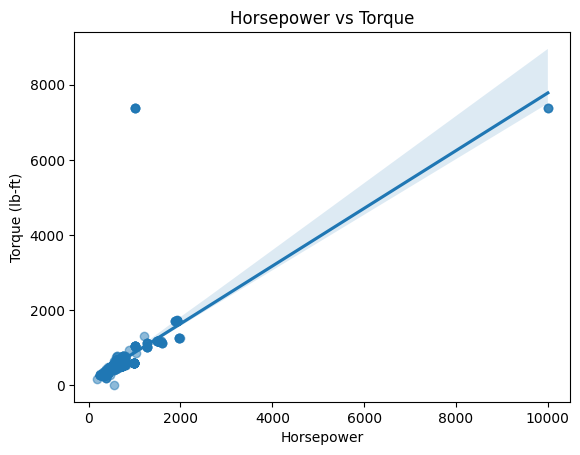

Spearman ρ = 0.90
p-value = 0.00e+00


In [19]:
sns.regplot(
    data=df,
    x='Horsepower',
    y='Torque (lb-ft)',
    scatter_kws={'alpha': 0.5}
)

plt.title('Horsepower vs Torque')
plt.xlabel('Horsepower')
plt.ylabel('Torque (lb-ft)')
plt.show()

rho, p = spearmanr(
    df['Horsepower'],
    df['Torque (lb-ft)']
)

print(f'Spearman ρ = {rho:.2f}')
print(f'p-value = {p:.2e}')

In [20]:
df.loc[df["Powertrain Type"] == "Electric", "Engine Size (L)"] = 0

ice_median = df.loc[df["Powertrain Type"] == "ICE", "Engine Size (L)"].median()

df.loc[(df["Powertrain Type"] == "Hybrid") & (df["Engine Size (L)"].isna()), "Engine Size (L)"] = ice_median

---
##Save Cleaned Data

In [21]:
from google.colab import files

df.to_csv('car_price_cleaned.csv', index=False)

files.download('car_price_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>